**MAESTRÍA EN ECONOMÍA APLICADA - UBA 2025**
**TALLER DE PROGRAMACIÓN**
**GRUPO 2**

In [1]:
# Carga de usuario para simplificar paths de acceso según quién ejecute el código
print("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
usuario = input("Ingrese su número de referencia de usuario de la lista\nAlvarez - 1\nGodino - 2\nSulca - 3\nOtro usuario - 4:")
if usuario == '1':
    nombre = "Alvarez"
    path = "C:\\Users\\marti\\OneDrive\\Documentos\\"
elif usuario == '2':
    nombre = "Alvarez"
    path = "C:\\Users\\Usuario\\Documents\\"
elif usuario == '3':
    nombre = "Alvarez"
    path = "C:\\Users\\user\\Documents\\"
elif usuario == '4':
    print("A modo de ejemplo, el path a la carpeta Github debe tener esta forma: C:\\Users\\Usuario\\Documents\\")
    path = input("Ingrese el path en su computadora a la carpeta Github: ")
print(f"Path cargado correctamente")

Ingrese su número de referencia de usuario de la lista
Alvarez - 1
Godino - 2
Sulca - 3
Otro usuario - 4:
Path cargado correctamente


In [2]:
# Librerías a utilizar
# !pip install openpyxl - utilizar en caso no te cargue el archivo de excel
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# TP3

In [3]:
# Importamos la base construida en el TP1
respondieron = pd.read_csv(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\respondieron.csv")
norespondieron = pd.read_csv(path+"GitHub\\Big-Data-UBA--Grupo-2\\base de datos\\norespondieron.csv")

## PARTE A: Separación train/test por año

In [4]:
# ======================
# Separar respondieron
# ======================
respondieron_2005 = respondieron[respondieron['df'] == 'T105'].copy()
respondieron_2025 = respondieron[respondieron['df'] == 'T125'].copy()

# ======================
# Separar norespondieron
# ======================
norespondieron_2005 = norespondieron[norespondieron['df'] == 'T105'].copy()
norespondieron_2025 = norespondieron[norespondieron['df'] == 'T125'].copy()


In [5]:
# ======================
# SELECCIÓN DE VARIABLES (sin ingresos)
# ======================
              # Sexo, Edad, Estado Civil, Nivel Educativo, Estado Ocup, Inactividad, Ocupación, Meses buscando empleo, Buscó más horas
variables_X = ['ch04', 'ch06', 'ch07', 'nivel_ed', 'estado', 'cat_inac', 'cat_ocup', 'pp10a', 'pp03i' ]

#### 2005
#########

X = respondieron_2005[variables_X].copy()
y = respondieron_2005['pobre'].astype(int)
# Agregar intercepto (columna de unos)
X['intercept'] = 1

# TRAIN/TEST SPLIT
X_train_2005, X_test_2005, y_train_2005, y_test_2005 = train_test_split(
    X, y, test_size=0.30, random_state=444)

# TABLA DE MEDIAS ENTRE TRAIN Y TEST
tabla_medias = pd.DataFrame({
    'Media_Train': X_train_2005.mean(),
    'Media_Test': X_test_2005.mean(),
    'Diferencia': X_train_2005.mean() - X_test_2005.mean()
    })

tabla_medias.to_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\TP3\\tabla_medias_2005.xlsx")

#### 2025
#########

X = respondieron_2025[variables_X].copy()
y = respondieron_2025['pobre'].astype(int)
# Agregar intercepto (columna de unos)
X['intercept'] = 1

# TRAIN/TEST SPLIT
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = train_test_split(
    X, y, test_size=0.30, random_state=444)

# TABLA DE MEDIAS ENTRE TRAIN Y TEST
tabla_medias = pd.DataFrame({
    'Media_Train': X_train_2025.mean(),
    'Media_Test': X_test_2025.mean(),
    'Diferencia': X_train_2025.mean() - X_test_2025.mean()
    })

tabla_medias.to_excel(path+"GitHub\\Big-Data-UBA--Grupo-2\\TP3\\tabla_medias_2025.xlsx")

## PARTE B. Modelo de Regresion Logística

In [6]:
# Revisamos NaNs
print(X_train_2025.shape)
print(X_train_2025.isna().sum())
# Rellenamos con ceros los NaNs ya que para esas variables 0 no es un valor utilizado
X_train_2025 = X_train_2025.fillna(0)
X_test_2025 = X_test_2025.fillna(0)

(6086, 10)
ch04            0
ch06            0
ch07            0
nivel_ed        0
estado          0
cat_inac     2863
cat_ocup     3256
pp10a        5951
pp03i        3360
intercept       0
dtype: int64


In [7]:
import statsmodels.api as sm
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


# Modelo para 2025
logit_model = sm.Logit(y_train_2025, X_train_2025)
resultado = logit_model.fit()
print(resultado.summary2())

# Guardamos los coeficientes
coeficientes = resultado.params[:]  # Excluir el intercepto

# Calculamos los odds ratio
odds_ratio = np.exp(coeficientes)

# Guardamos el error estándar
std_error = resultado.bse[:]  # Excluir el intercepto

# Creamos la tabla
tabla_resultados = pd.DataFrame({
    #'Variable': X.columns esta linea para cuando tengan muchas variables
    'Coeficiente': coeficientes,
    'Std. Error': std_error,
    'Odds Ratio': odds_ratio
})

tabla_resultados.round(2)

Optimization terminated successfully.
         Current function value: 0.614587
         Iterations 5
                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: pobre            Pseudo R-squared: 0.106      
Date:               2025-11-18 22:47 AIC:              7500.7512  
No. Observations:   6086             BIC:              7567.8886  
Df Model:           9                Log-Likelihood:   -3740.4    
Df Residuals:       6076             LL-Null:          -4182.0    
Converged:          1.0000           LLR p-value:      2.5649e-184
No. Iterations:     5.0000           Scale:            1.0000     
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
ch04           0.1200    0.0568    2.1120  0.0347   0.0086   0.2313
ch06          -0.0317    0.0018  -17.9483  0.0000

,Coeficiente,Std. Error,Odds Ratio
ch04,0.12,0.06,1.13
ch06,-0.03,0.00,0.97
ch07,-0.11,0.02,0.90
nivel_ed,-0.23,0.02,0.80
estado,-0.94,0.08,0.39
cat_inac,0.29,0.03,1.33
cat_ocup,-0.11,0.06,0.90
pp10a,0.37,0.08,1.45
pp03i,-0.60,0.09,0.55
intercept,4.10,0.31,60.14


In [8]:
# Predicción para ver rango
y_pred_score = resultado.predict(X_test_2025)  
print('promedio de predicción Prob(y=1|X): ', y_pred_score.mean().round(3))
print('min de predicción Prob(y=1|X): ', y_pred_score.min().round(3))
print('max de predicción Prob(y=1|X): ', y_pred_score.max().round(3))
# Adentro del rango!

promedio de predicción Prob(y=1|X):  0.446


AttributeError: 'float' object has no attribute 'round'

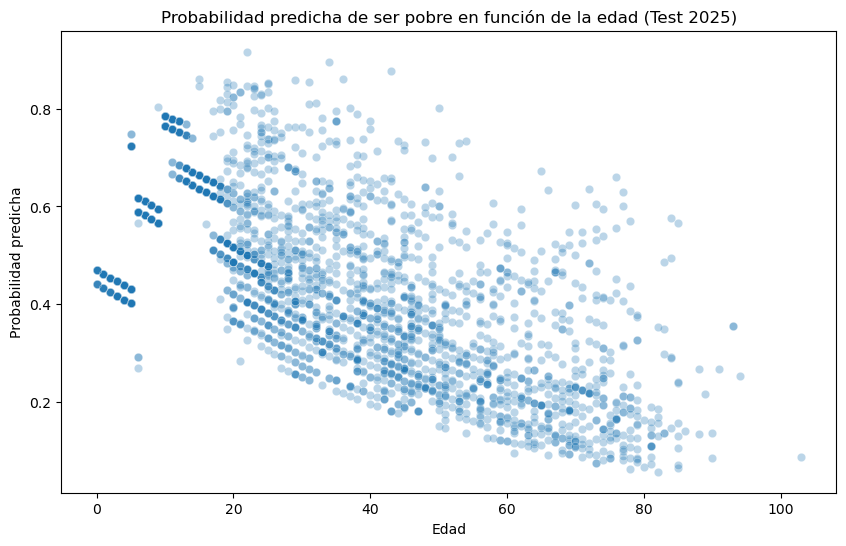

In [9]:
# =========================================
# CONSIGNA 4: Gráfico de la probabilidad predicha en test en función de edad
# =========================================

# Unimos en un df edad y predicción
datos = pd.DataFrame({
    'edad': X_test_2025['ch06'],
    'prediccion': y_pred_score
})

# Graficamos
plt.figure(figsize=(10,6))
sns.scatterplot(data=datos, x='edad', y='prediccion', alpha=0.3)
plt.title('Probabilidad predicha de ser pobre en función de la edad (Test 2025)')
plt.xlabel('Edad')
plt.ylabel('Probabilidad predicha')
plt.show()

## PARTE C. Método de Vecinos Cercanos (KNN)

Consigna 5

In [10]:
variables_knn = variables_X.copy()   # mismas variables que para el logit
variables_knn.append('pobre')

# Hacemos train con SOLO esas variables
train_knn = pd.concat([X_train_2025, y_train_2025], axis=1)

# Eliminamos solo filas donde falten datos relevantes
train_knn = train_knn.dropna(subset=variables_knn)

# Reconstruimos X y y limpios
X_train_knn = train_knn[X_train_2025.columns]
y_train_knn = train_knn['pobre']

print("Filas disponibles para KNN:", X_train_knn.shape[0])


Filas disponibles para KNN: 6086


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

K_values = [1, 5, 10]
resultados_knn = {}

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_knn)

    y_pred = knn.predict(X_train_knn)
    acc = accuracy_score(y_train_knn, y_pred)

    resultados_knn[k] = acc
    print(f"K={k}: Accuracy (train) = {acc:.4f}")


K=1: Accuracy (train) = 0.7861
K=5: Accuracy (train) = 0.7116
K=10: Accuracy (train) = 0.6875


Consigna 6

In [12]:
# ==================================
# 6) Visualización de fronteras KNN
# ==================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Seleccionar dos variables numéricas
var1 = "ch06"
var2 = "ad_equiv_hogar"

X_plot = X_train_knn[[var1, var2]].values
y_plot = y_train_knn.values

# Crear una malla para dibujar la frontera
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

for ax, k in zip(axes, [1, 10]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_plot, y_plot)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap='viridis', edgecolors='k')
    ax.set_title(f"Frontera de clasificación KNN (K={k})")
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)

plt.tight_layout()
plt.show()


KeyError: "['ad_equiv_hogar'] not in index"

Consigna 7

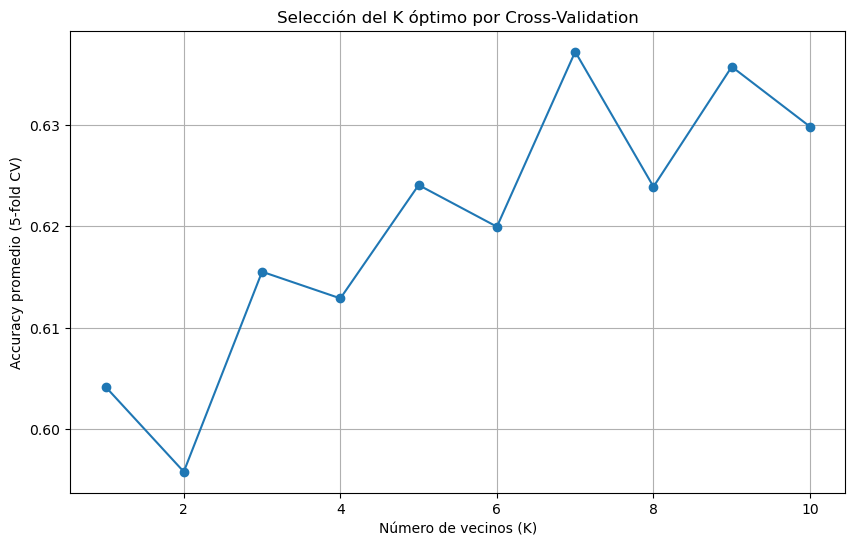

➡️ El K óptimo por 5-fold CV es: 7


In [13]:
# ==========================================
# 7) Selección de K óptimo por 5-fold CV
# ==========================================

from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

K_range = range(1, 11)
cv_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=444)

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, 
                             X_train_knn, 
                             y_train_knn,
                             cv=kf, 
                             scoring='accuracy')
    cv_scores.append(scores.mean())

# Gráfico del accuracy por K
plt.figure(figsize=(10,6))
plt.plot(K_range, cv_scores, marker='o')
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio (5-fold CV)")
plt.title("Selección del K óptimo por Cross-Validation")
plt.grid(True)
plt.show()

best_k = K_range[np.argmax(cv_scores)]
print(f"➡️ El K óptimo por 5-fold CV es: {best_k}")


Parte D. Desempeño de modelos afuera de la muestra, métricas y politicas públicas

Consigna 8

1. MATRIZ DE CONFUSIÓN — LOGIT (umbral p > 0.5)

In [14]:
from sklearn.metrics import confusion_matrix

# Predicción con LOGIT en test
y_pred_logit_prob = resultado.predict(X_test_2025)
y_pred_logit = (y_pred_logit_prob > 0.5).astype(int)

cm_logit = confusion_matrix(y_test_2025, y_pred_logit)
cm_logit


array([[1053,  378],
       [ 546,  632]])

2. CURVA ROC — LOGIT vs KNN (K óptimo)

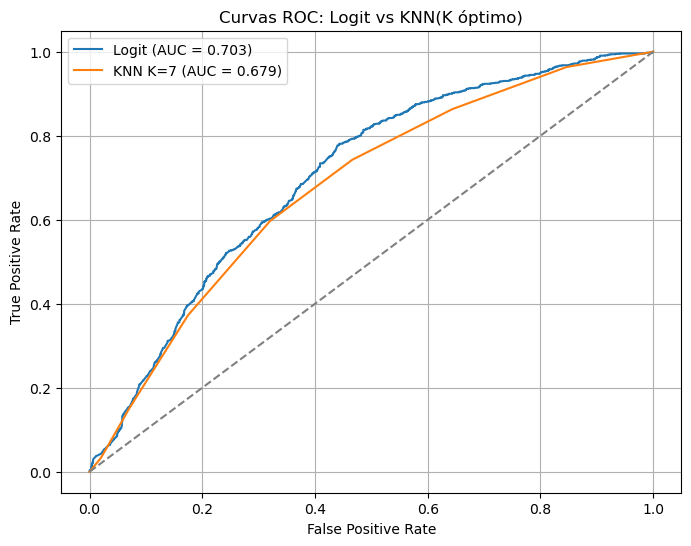

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Entrenar KNN con K óptimo
knn_cv = KNeighborsClassifier(n_neighbors=best_k)
knn_cv.fit(X_train_knn, y_train_knn)

# Probabilidades para curva ROC (en KNN es proporción de vecinos)
y_pred_knn_prob = knn_cv.predict_proba(X_test_2025)[:,1]

# ROC Logit
fpr_logit, tpr_logit, _ = roc_curve(y_test_2025, y_pred_logit_prob)
roc_auc_logit = auc(fpr_logit, tpr_logit)

# ROC KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test_2025, y_pred_knn_prob)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {roc_auc_logit:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN K={best_k} (AUC = {roc_auc_knn:.3f})")
plt.plot([0,1], [0,1], '--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC: Logit vs KNN(K óptimo)")
plt.legend()
plt.grid(True)
plt.show()


3. TABLA DE MÉTRICAS (Accuracy – F1 – Recall – Precision)

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metricas = pd.DataFrame({
    "Modelo": ["Logit", f"KNN (K={best_k})"],
    "Accuracy": [
        accuracy_score(y_test_2025, y_pred_logit),
        accuracy_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Precision": [
        precision_score(y_test_2025, y_pred_logit),
        precision_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "Recall": [
        recall_score(y_test_2025, y_pred_logit),
        recall_score(y_test_2025, knn_cv.predict(X_test_2025))
    ],
    "F1-score": [
        f1_score(y_test_2025, y_pred_logit),
        f1_score(y_test_2025, knn_cv.predict(X_test_2025))
    ]
})

metricas


,Modelo,Accuracy,Precision,Recall,F1-score
0,Logit,0.645841,0.625743,0.536503,0.577697
1,KNN (K=7),0.642392,0.605512,0.596774,0.601112


TP 4

PARTE A

A. Modelo de Regresión Logística con Regularización: Ridge y LASSO

In [18]:
import pandas as pd
import numpy as np

# Copia limpia
X_train = X_train_2025.copy()
y_train = y_train_2025.copy().astype(int)

# Eliminar filas con NA
df_train = pd.concat([X_train, y_train], axis=1).dropna()

X_train = df_train[X_train.columns]
y_train = df_train[y_train.name]

print("Filas finales para entrenamiento:", X_train.shape[0])


Filas finales para entrenamiento: 6086


A1 — Visualización de coeficientes LASSO y Ridge

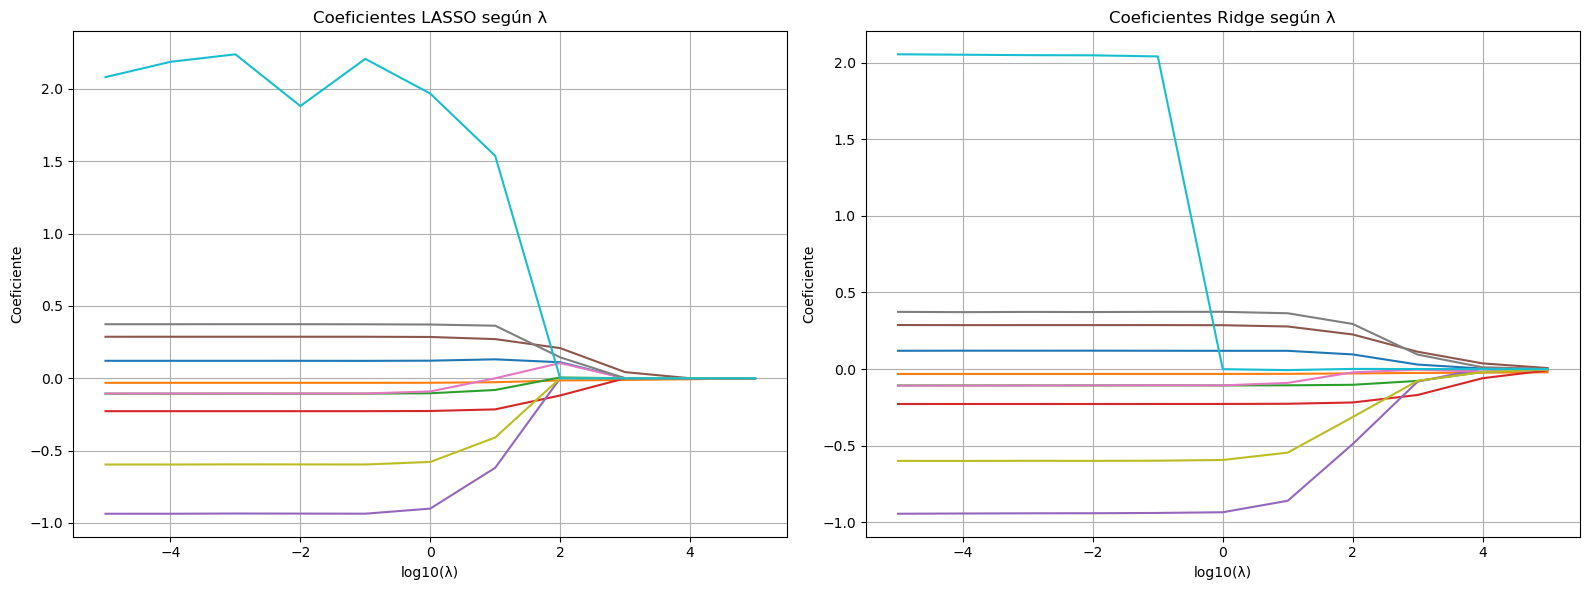

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Grilla λ = 10^n
n_values = np.arange(-5, 6)      # -5 a +5
lambdas = 10.0**n_values
C_values = 1 / lambdas           # C = 1/λ

variables = X_train.columns

coef_lasso = []
coef_ridge = []

for C in C_values:
    # LASSO
    model_l1 = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=C,
        max_iter=800
    )
    model_l1.fit(X_train, y_train)
    coef_lasso.append(model_l1.coef_[0])

    # RIDGE
    model_l2 = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=C,
        max_iter=800
    )
    model_l2.fit(X_train, y_train)
    coef_ridge.append(model_l2.coef_[0])

coef_lasso = np.array(coef_lasso)
coef_ridge = np.array(coef_ridge)

# ============ GRÁFICOS ==================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LASSO
for i in range(coef_lasso.shape[1]):
    axes[0].plot(n_values, coef_lasso[:, i])
axes[0].set_title("Coeficientes LASSO según λ")
axes[0].set_xlabel("log10(λ)")
axes[0].set_ylabel("Coeficiente")
axes[0].grid(True)

# Ridge
for i in range(coef_ridge.shape[1]):
    axes[1].plot(n_values, coef_ridge[:, i])
axes[1].set_title("Coeficientes Ridge según λ")
axes[1].set_xlabel("log10(λ)")
axes[1].set_ylabel("Coeficiente")
axes[1].grid(True)

plt.tight_layout()
plt.show()


A2 — Penalidad óptima con Cross-Validation

λ óptimo (LASSO): 0.0001
λ óptimo (Ridge): 1e-05


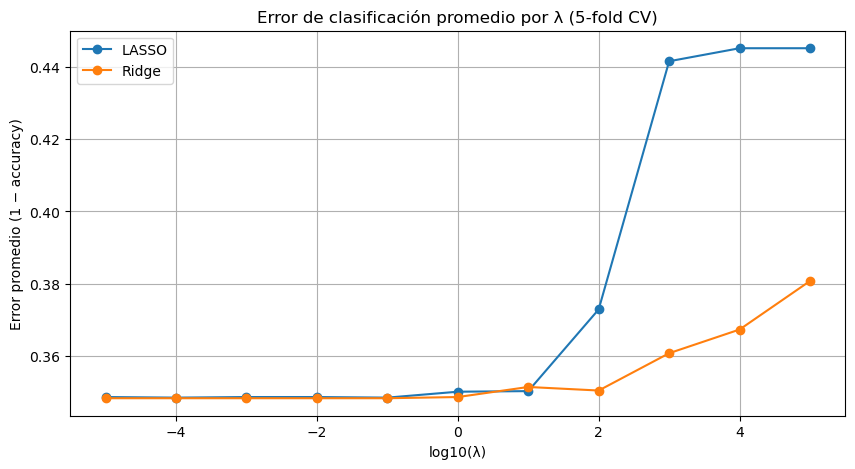

In [21]:
from sklearn.linear_model import LogisticRegressionCV

# Grilla de C
C_values = 1 / (10.0**n_values)

# LASSO con CV
lasso_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty="l1",
    solver="liblinear",
    max_iter=800,
    scoring="accuracy"
)
lasso_cv.fit(X_train, y_train)

# RIDGE con CV
ridge_cv = LogisticRegressionCV(
    Cs=C_values,
    cv=5,
    penalty="l2",
    solver="lbfgs",
    max_iter=800,
    scoring="accuracy"
)
ridge_cv.fit(X_train, y_train)

best_lambda_lasso = 1 / lasso_cv.C_[0]
best_lambda_ridge = 1 / ridge_cv.C_[0]

print("λ óptimo (LASSO):", best_lambda_lasso)
print("λ óptimo (Ridge):", best_lambda_ridge)

# Gráfico error por λ
mean_scores_lasso = lasso_cv.scores_[1].mean(axis=0)
mean_scores_ridge = ridge_cv.scores_[1].mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(n_values, 1 - mean_scores_lasso, marker="o", label="LASSO")
plt.plot(n_values, 1 - mean_scores_ridge, marker="o", label="Ridge")
plt.xlabel("log10(λ)")
plt.ylabel("Error promedio (1 − accuracy)")
plt.title("Error de clasificación promedio por λ (5-fold CV)")
plt.grid(True)
plt.legend()
plt.show()


A3 — Estimación final y tabla comparativa

In [23]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# ===== (1) Modelo sin penalidad =====
logit_none = LogisticRegression(
    penalty=None,     # <-- CORREGIDO
    solver="lbfgs",
    max_iter=800
)
logit_none.fit(X_train, y_train)
coef_none = logit_none.coef_[0]

# ===== (2) Modelo LASSO con λ óptimo =====
logit_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=lasso_cv.C_[0],   # λ óptimo invertido
    max_iter=800
)
logit_l1.fit(X_train, y_train)
coef_l1 = logit_l1.coef_[0]

# ===== (3) Modelo Ridge con λ óptimo =====
logit_l2 = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    C=ridge_cv.C_[0],   # λ óptimo invertido
    max_iter=800
)
logit_l2.fit(X_train, y_train)
coef_l2 = logit_l2.coef_[0]

# ===== (4) Tabla de comparación =====
tabla_coef = pd.DataFrame({
    "Variable": X_train.columns,
    "Logit_sin_penalidad": coef_none,
    "LASSO_L1": coef_l1,
    "Ridge_L2": coef_l2
})

# Mostrar tabla ordenada por valor absoluto del coeficiente sin penalidad
tabla_coef.sort_values(by="Logit_sin_penalidad", ascending=False)


,Variable,Logit_sin_penalidad,LASSO_L1,Ridge_L2
9,intercept,2.048824,1.935138,2.053677
7,pp10a,0.371820,0.373188,0.373227
5,cat_inac,0.286744,0.286909,0.287385
0,ch04,0.119656,0.120164,0.119421
1,ch06,-0.031748,-0.031724,-0.031781
2,ch07,-0.106823,-0.106628,-0.106920
6,cat_ocup,-0.107160,-0.106657,-0.108608
3,nivel_ed,-0.227661,-0.227638,-0.227899
8,pp03i,-0.599148,-0.597468,-0.599045
4,estado,-0.940963,-0.939246,-0.943872


PARTE B

B4 — Árbol de Decisión podado (CART) + 10-fold CV para elegir ccp_alpha

Cantidad de alphas válidos después del filtrado: 486
Primeros valores de alpha: [8.67361738e-19 3.70638408e-07 6.31967441e-07 7.82435879e-07
 9.78044849e-07]


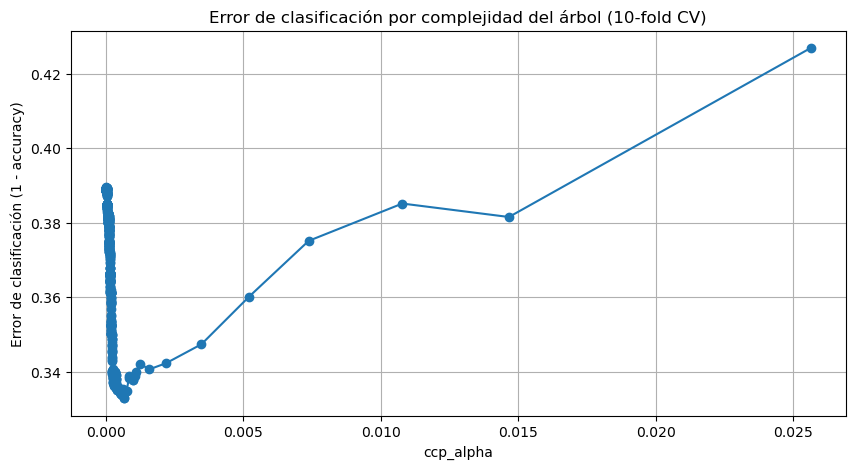


➡️ Mejor ccp_alpha según 10-fold CV: 0.0006452981651215561


In [25]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Obtener grilla inicial de ccp_alpha
# ------------------------------------------
path = DecisionTreeClassifier(random_state=123).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# ------------------------------------------
# 2. Limpieza: eliminar negativos y ceros
# ------------------------------------------
ccp_alphas = ccp_alphas[ccp_alphas > 0]   # solo positivos estrictos
ccp_alphas = np.unique(ccp_alphas)        # por si hubiera duplicados

# Reducir a valores razonables (evita árboles degenerados)
ccp_alphas = ccp_alphas[ccp_alphas < 0.05]

print("Cantidad de alphas válidos después del filtrado:", len(ccp_alphas))
print("Primeros valores de alpha:", ccp_alphas[:5])

# ------------------------------------------
# 3. Cross-Validation 10-fold para cada alpha
# ------------------------------------------
cv_scores = []

for ccp in ccp_alphas:
    tree = DecisionTreeClassifier(
        random_state=123,
        ccp_alpha=float(ccp)   # aseguramos float nativo
    )
    scores = cross_val_score(tree, X_train, y_train, cv=10, scoring="accuracy")
    cv_scores.append(scores.mean())

# ------------------------------------------
# 4. Gráfico del error de clasificación
# ------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(ccp_alphas, 1 - np.array(cv_scores), marker="o")
plt.xlabel("ccp_alpha")
plt.ylabel("Error de clasificación (1 - accuracy)")
plt.title("Error de clasificación por complejidad del árbol (10-fold CV)")
plt.grid(True)
plt.show()

# ------------------------------------------
# 5. Mejor alpha
# ------------------------------------------
best_alpha = ccp_alphas[np.argmax(cv_scores)]
print("\n➡️ Mejor ccp_alpha según 10-fold CV:", best_alpha)


B5 — Visualización del árbol podado + Importancia de variables

Panel A — Visualización del árbol podado

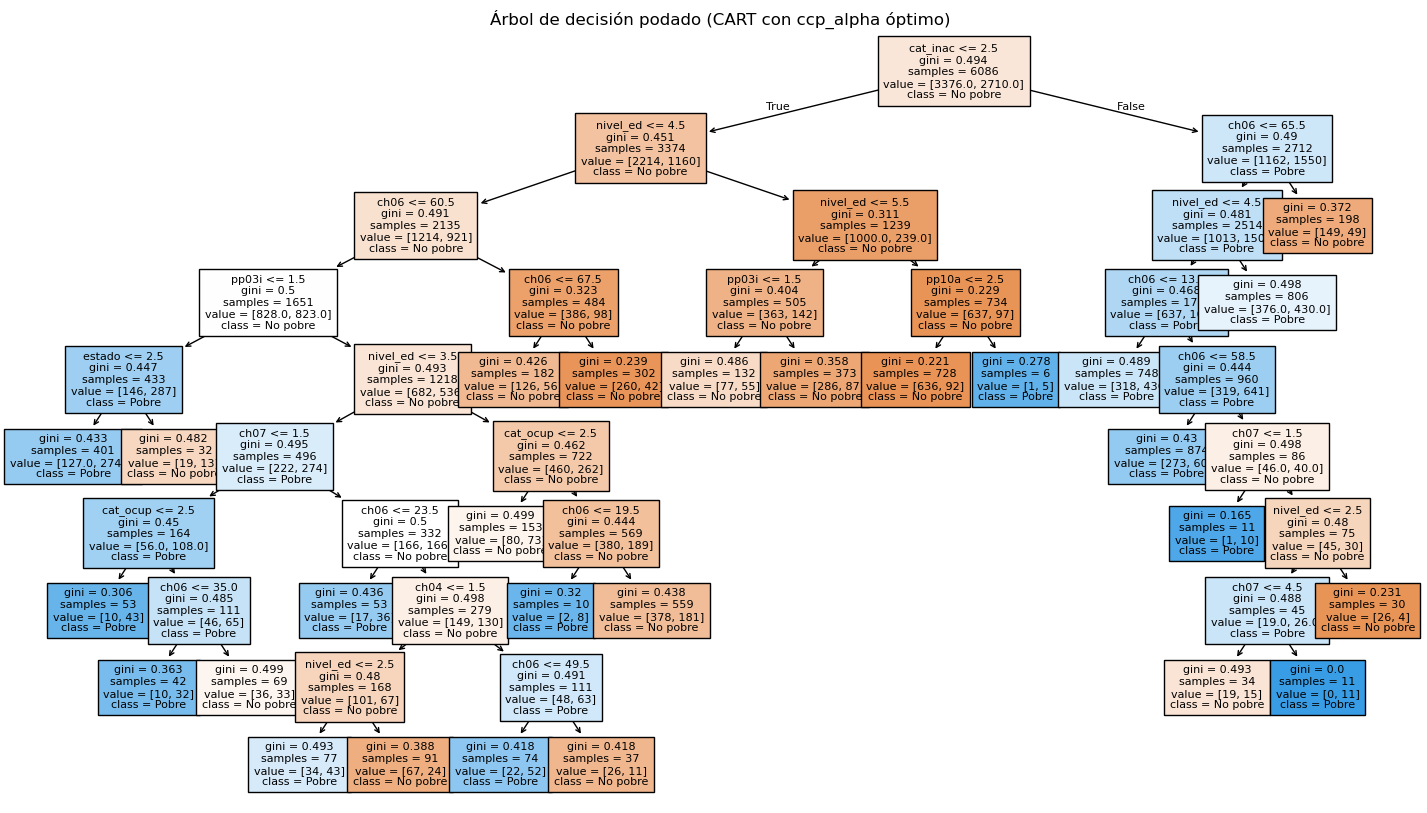

In [26]:
from sklearn import tree
import matplotlib.pyplot as plt

# Entrenamos el árbol final con alpha óptimo
tree_pruned = DecisionTreeClassifier(
    random_state=123,
    ccp_alpha=best_alpha
)
tree_pruned.fit(X_train, y_train)

# Plot del árbol
plt.figure(figsize=(18, 10))
tree.plot_tree(
    tree_pruned,
    feature_names=X_train.columns,
    class_names=["No pobre", "Pobre"],
    filled=True,
    fontsize=8
)
plt.title("Árbol de decisión podado (CART con ccp_alpha óptimo)")
plt.show()


Panel B — Importancia de variables

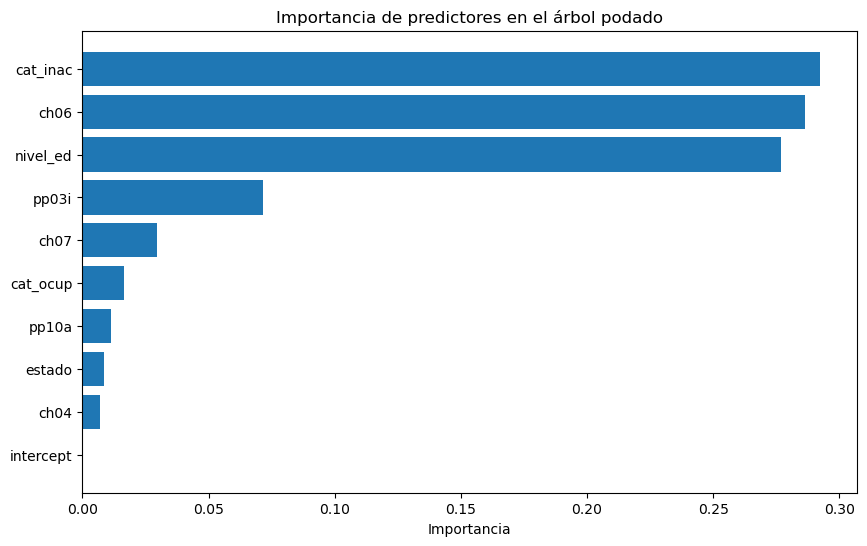

In [27]:
import numpy as np

importances = tree_pruned.feature_importances_
order = np.argsort(importances)[::-1]  # de mayor a menor

plt.figure(figsize=(10,6))
plt.barh(np.array(X_train.columns)[order], importances[order])
plt.xlabel("Importancia")
plt.title("Importancia de predictores en el árbol podado")
plt.gca().invert_yaxis()
plt.show()


PARTE C

C6 — Código completo: matrices, ROC, métricas y comparación

Matriz de confusión - Logit sin penalidad:
 [[1053  378]
 [ 546  632]]


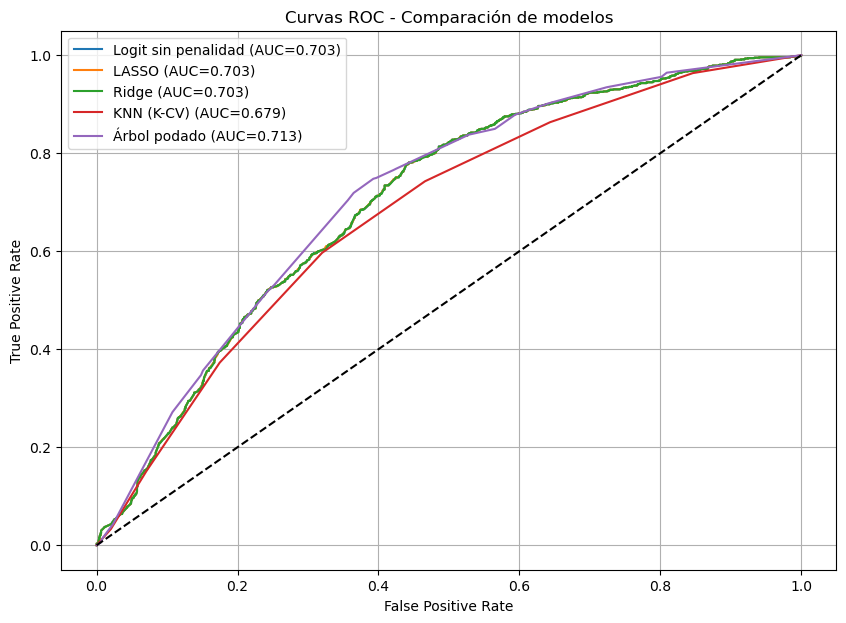



Tabla comparativa de métricas:
                     Accuracy  Precision    Recall        F1
Logit sin penalidad  0.645841   0.625743  0.536503  0.577697
LASSO                0.645841   0.625743  0.536503  0.577697
Ridge                0.645841   0.625743  0.536503  0.577697
KNN (K-CV)           0.642392   0.605512  0.596774  0.601112
Árbol podado         0.670755   0.619119  0.703735  0.658721


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Predicciones de cada modelo
# -------------------------------------------------------

# LOGIT sin penalidad
prob_logit_none = logit_none.predict_proba(X_test_2025)[:, 1]
pred_logit_none = (prob_logit_none > 0.5).astype(int)

# LASSO
prob_l1 = logit_l1.predict_proba(X_test_2025)[:, 1]
pred_l1 = (prob_l1 > 0.5).astype(int)

# RIDGE
prob_l2 = logit_l2.predict_proba(X_test_2025)[:, 1]
pred_l2 = (prob_l2 > 0.5).astype(int)

# KNN con K-CV
prob_knn = knn_cv.predict_proba(X_test_2025)[:, 1]
pred_knn = (prob_knn > 0.5).astype(int)

# Árbol podado
prob_tree = tree_pruned.predict_proba(X_test_2025)[:, 1]
pred_tree = (prob_tree > 0.5).astype(int)


# -------------------------------------------------------
# 2. Matriz de confusión (Logit sin penalidad)
# -------------------------------------------------------
cm_logit_none = confusion_matrix(y_test_2025, pred_logit_none)
print("Matriz de confusión - Logit sin penalidad:\n", cm_logit_none)


# -------------------------------------------------------
# 3. Curva ROC comparada
# -------------------------------------------------------

plt.figure(figsize=(10,7))

models_prob = {
    "Logit sin penalidad": prob_logit_none,
    "LASSO": prob_l1,
    "Ridge": prob_l2,
    "KNN (K-CV)": prob_knn,
    "Árbol podado": prob_tree
}

for name, prob in models_prob.items():
    fpr, tpr, _ = roc_curve(y_test_2025, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Comparación de modelos")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------------
# 4. Tabla comparativa de métricas
# -------------------------------------------------------

def metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "Logit sin penalidad": metrics(y_test_2025, pred_logit_none),
    "LASSO": metrics(y_test_2025, pred_l1),
    "Ridge": metrics(y_test_2025, pred_l2),
    "KNN (K-CV)": metrics(y_test_2025, pred_knn),
    "Árbol podado": metrics(y_test_2025, pred_tree),
}).T

print("\n\nTabla comparativa de métricas:")
print(results)

# Error
results["1 - Accuracy"] = 1 - results["Accuracy"]


C7 — Código: identificar el “mejor modelo” para el Ministerio

In [31]:
from sklearn.metrics import roc_curve, auc

# Mejor modelo según Recall (criterio del Ministerio)
best_by_recall = results["Recall"].idxmax()

# Mejor modelo por AUC
best_by_auc = max(
    models_prob.keys(),
    key=lambda m: auc(
        roc_curve(y_test_2025, models_prob[m])[0],   # fpr
        roc_curve(y_test_2025, models_prob[m])[1]    # tpr
    )
)

print("➡️ Mejor modelo según Recall (Ministerio):", best_by_recall)
print("➡️ Mejor modelo según AUC:", best_by_auc)


➡️ Mejor modelo según Recall (Ministerio): Árbol podado
➡️ Mejor modelo según AUC: Árbol podado
